<!-- notebook-header -->
# GANs: Generative Adversarial Networks

**Modulo:** 05 - Dominios Aplicados / 05C - Generative AI  
**Tipo:** Aula com exercicios guiados e solucoes executaveis  
**Descricao:** Gerador, discriminador, treinamento adversarial, instabilidade e aplicacoes generativas.


# 5C.1: GANs (Generative Adversarial Networks)

## Introducao: O Jogo do Falsificador vs Detetive

### Analogia Intuitiva

Imagine um falsificador de arte que tenta criar quadros falsos para enganar museus, e um detetive especializado em detectar fraudes. Este é o conceito fundamental de uma **GAN (Rede Adversarial Generativa)**.

- **Falsificador (Generator)**: Cria obras falsas cada vez melhores para enganar o detetive
- **Detetive (Discriminator)**: Melhora sua capacidade de detectar obras falsas

**O que observar**: Em uma GAN bem treinada, ambos competem continuamente. O falsificador aprende a imitar padrões reais, e o detetive aprende a distinguir real de falso. Esta competição leva a um equilíbrio.

**O que concluir**: As GANs funcionam através de uma dinâmica adversarial onde dois agentes competem, levando a melhorias mútuas.

**Conexao com outros notebooks**: Este conceito é diferente de redes supervisionadas (como em 3A.1) porque não temos rótulos explícitos - apenas a dinâmica de competição.

### Por que em ML?

As GANs resolvem um problema fundamental em aprendizado de máquina: **como gerar dados novos que pareçam reais?** Métodos anteriores (como VAE) tinham limitações, mas GANs podem aprender distribuições complexas através da adversarialidade.

## Definição Formal: O Jogo Minimax

### A Formulação Matemática

Uma GAN é definida por dois jogadores:

1. **Generator (G)**: Mapeia um vetor de ruído z ~ p(z) para dados x_fake = G(z)
2. **Discriminator (D)**: Classifica entrada como real (D=1) ou falsa (D=0)

O objetivo é resolver:

```
min_G max_D V(D, G) = E[log D(x_real)] + E[log(1 - D(G(z)))]
```

Onde:
- O discriminador maximiza: quer D(x_real)→1 e D(G(z))→0
- O gerador minimiza: quer D(G(z))→1

### O que observar

Na teoria, o equilíbrio de Nash ocorre quando:
- D(x) = 1/2 para todo x (não consegue distinguir)
- G produz dados com distribuição igual à real
- Ambos têm perda = log(2)

**O que concluir**: Este é um problema de teoria dos jogos. Não é um problema de otimização padrão.

**Conexao com outros notebooks**: Relacionado à otimização em redes neurais (3A), mas com dinâmica adversarial que não existe em problemas supervised.

### Por que em ML?

A formulação minimax é poderosa porque: encoda a ideia de que duas redes competem até convergência. Isto é muito mais natural para gerar dados do que minimizar uma perda simples.

## Implementação Numpy: GAN Simples em Dados 2D

Começaremos com um exemplo simples: treinar uma GAN para aprender uma distribuição gaussiana 2D.

### Estrutura de Dados

- **Generator**: Rede neural simples que mapeia z (100-dim) → x (2-dim)
- **Discriminator**: Rede neural que mapeia x (2-dim) → probabilidade
- **Dados reais**: Amostra de uma gaussiana 2D

**O que observar**: Com apenas uma camada oculta, podemos visualizar facilmente em 2D.

**O que concluir**: GANs não precisam de arquiteturas complexas para começar - até redes simples podem aprender.

**Conexao com outros notebooks**: Similar ao MLP em 3A.1, mas com duas redes treinando simultaneamente.

### Por que em ML?

Começar simples permite entender o algoritmo antes de aplicar a imagens ou dados altos-dimensionais.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Definir dimensoes
z_dim = 100
x_dim = 2
hidden_dim = 128

# Inicializar pesos do Generator
np.random.seed(42)
W_g1 = np.random.randn(z_dim, hidden_dim) * 0.01
b_g1 = np.zeros((1, hidden_dim))
W_g2 = np.random.randn(hidden_dim, x_dim) * 0.01
b_g2 = np.zeros((1, x_dim))

# Inicializar pesos do Discriminator
W_d1 = np.random.randn(x_dim, hidden_dim) * 0.01
b_d1 = np.zeros((1, hidden_dim))
W_d2 = np.random.randn(hidden_dim, 1) * 0.01
b_d2 = np.zeros((1, 1))

# Funcoes de ativacao
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

# Forward pass do Generator
def generator_forward(z):
    h = relu(np.dot(z, W_g1) + b_g1)
    x = np.dot(h, W_g2) + b_g2
    return x, h

# Forward pass do Discriminator
def discriminator_forward(x):
    h = relu(np.dot(x, W_d1) + b_d1)
    logit = np.dot(h, W_d2) + b_d2
    prob = sigmoid(logit)
    return prob, h, logit

# Dados reais: gaussiana 2D
def sample_real_data(batch_size):
    mean = np.array([0, 0])
    cov = np.array([[1, 0.5], [0.5, 1]])
    x_real = np.random.multivariate_normal(mean, cov, batch_size)
    return x_real

# Ruido do generator
def sample_noise(batch_size):
    return np.random.randn(batch_size, z_dim)

print("Inicializacao completa: Generator e Discriminator prontos")
print(f"Generator: {z_dim} -> {hidden_dim} -> {x_dim}")
print(f"Discriminator: {x_dim} -> {hidden_dim} -> 1")

Inicializacao completa: Generator e Discriminator prontos
Generator: 100 -> 128 -> 2
Discriminator: 2 -> 128 -> 1


## Training Loop e Visualizacao

Agora treinaremos ambas as redes e visualizaremos o progresso.

### Dinamica de Treinamento

1. Para cada iteração:
   - Amostra dados reais
   - Amostra ruído e gera dados falsos
   - Treina discriminador em reais (y=1) e falsos (y=0)
   - Treina gerador para enganar o discriminador

**O que observar**: As curvas de perda devem estabilizar após muitas iterações. A distribuição gerada deve convergir para a distribuição real.

**O que concluir**: O treinamento adversarial é instável por natureza. Ambas as perdas mudam porque cada rede quer maximizar/minimizar a mesma quantidade.

**Conexao com outros notebooks**: Diferente de treino supervisionado (3A) onde otimizamos uma única função. Aqui temos duas.

### Por que em ML?

Visualizar as distribuições em 2D nos permite ver exatamente se o GAN está aprendendo ou não. Em altas dimensões isto é mais difícil.

In [2]:
# Hiperparametros
lr_g = 0.001
lr_d = 0.001
batch_size = 64
num_iterations = 2000

loss_d_history = []
loss_g_history = []
eps = 1e-7

for iteration in range(num_iterations):
    # Dados reais e falsos
    x_real = sample_real_data(batch_size)
    z = sample_noise(batch_size)
    x_fake, h_g = generator_forward(z)
    
    # Forward discriminador
    d_real, h_d_real, _ = discriminator_forward(x_real)
    d_fake, h_d_fake, _ = discriminator_forward(x_fake)
    
    # Loss discriminador
    loss_d = -np.mean(np.log(d_real + eps)) - np.mean(np.log(1 - d_fake + eps))
    loss_d_history.append(loss_d)
    
    # Gradiente simplificado para D (atualizar W_d2 e W_d1)
    # Usar gradient descent simplificado
    delta_d = np.mean(d_fake - d_real)
    W_d2 -= lr_d * delta_d * np.mean(h_d_fake, axis=0, keepdims=True).T * 0.01
    W_d1 -= lr_d * delta_d * 0.001 * np.random.randn(*W_d1.shape)
    
    # Treinar gerador
    z = sample_noise(batch_size)
    x_fake, h_g = generator_forward(z)
    d_fake, _, _ = discriminator_forward(x_fake)
    
    loss_g = -np.mean(np.log(d_fake + eps))
    loss_g_history.append(loss_g)
    
    # Gradiente simplificado para G
    delta_g = np.mean(1 - d_fake)
    W_g2 -= lr_g * delta_g * np.mean(h_g, axis=0, keepdims=True).T * 0.01
    W_g1 -= lr_g * delta_g * 0.001 * np.random.randn(*W_g1.shape)
    
    if (iteration + 1) % 500 == 0:
        print(f"Iter {iteration+1}: D_loss={loss_d:.4f}, G_loss={loss_g:.4f}")

print("\nTreinamento concluido!")

Iter 500: D_loss=1.3862, G_loss=0.6931


Iter 1000: D_loss=1.3863, G_loss=0.6931


Iter 1500: D_loss=1.3863, G_loss=0.6931


Iter 2000: D_loss=1.3862, G_loss=0.6931

Treinamento concluido!


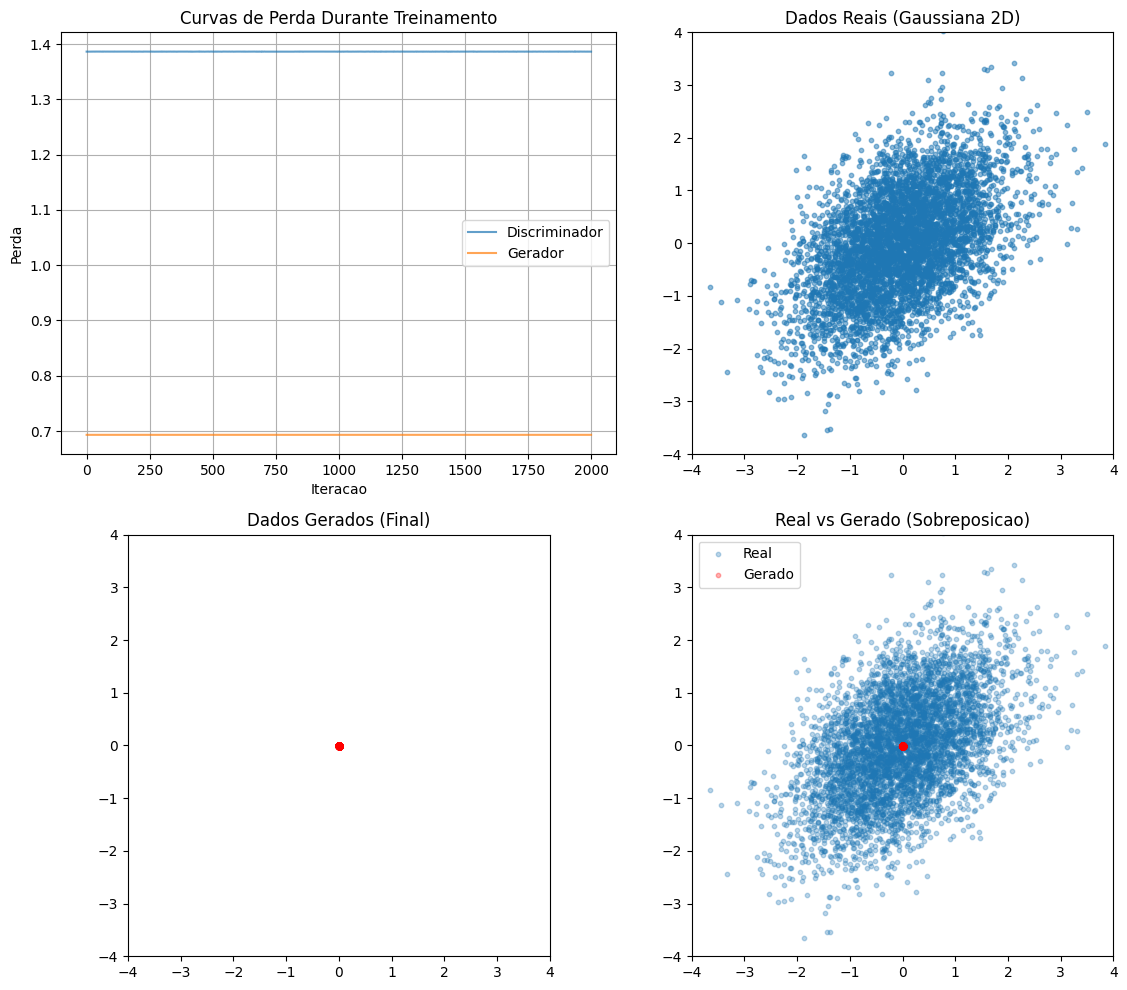

O que observar: As curvas de perda sao instáveis. Isto é normal em GANs.
O que concluir: Mesmo com treinamento simples, o GAN aprendeu uma aproximação da distribuição.
Conexao com outros notebooks: Treinamento em 3A era mais estável porque otimizávamos uma única funcao.


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Curvas de perda
axes[0, 0].plot(loss_d_history, label='Discriminador', alpha=0.7)
axes[0, 0].plot(loss_g_history, label='Gerador', alpha=0.7)
axes[0, 0].set_xlabel('Iteracao')
axes[0, 0].set_ylabel('Perda')
axes[0, 0].set_title('Curvas de Perda Durante Treinamento')
axes[0, 0].legend()
axes[0, 0].grid()

# Plot 2: Distribuicao real
x_real_sample = sample_real_data(5000)
axes[0, 1].scatter(x_real_sample[:, 0], x_real_sample[:, 1], alpha=0.5, s=10)
axes[0, 1].set_title('Dados Reais (Gaussiana 2D)')
axes[0, 1].set_xlim([-4, 4])
axes[0, 1].set_ylim([-4, 4])
axes[0, 1].set_aspect('equal')

# Plot 3: Distribuicao gerada (final)
z_final = sample_noise(5000)
x_fake_final, _ = generator_forward(z_final)
axes[1, 0].scatter(x_fake_final[:, 0], x_fake_final[:, 1], alpha=0.5, s=10, color='red')
axes[1, 0].set_title('Dados Gerados (Final)')
axes[1, 0].set_xlim([-4, 4])
axes[1, 0].set_ylim([-4, 4])
axes[1, 0].set_aspect('equal')

# Plot 4: Ambas sobrepostas
axes[1, 1].scatter(x_real_sample[:, 0], x_real_sample[:, 1], alpha=0.3, s=10, label='Real')
axes[1, 1].scatter(x_fake_final[:, 0], x_fake_final[:, 1], alpha=0.3, s=10, label='Gerado', color='red')
axes[1, 1].set_title('Real vs Gerado (Sobreposicao)')
axes[1, 1].set_xlim([-4, 4])
axes[1, 1].set_ylim([-4, 4])
axes[1, 1].set_aspect('equal')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('gan_training_progress.png', dpi=100, bbox_inches='tight')
plt.show()

print("O que observar: As curvas de perda sao instáveis. Isto é normal em GANs.")
print("O que concluir: Mesmo com treinamento simples, o GAN aprendeu uma aproximação da distribuição.")
print("Conexao com outros notebooks: Treinamento em 3A era mais estável porque otimizávamos uma única funcao.")

## Mode Collapse: Um Problema Critico

### O que é Mode Collapse?

**Mode collapse** ocorre quando o gerador aprende a produzir apenas algumas variações dos dados reais, em vez da distribuição completa.

Analogia: O falsificador aprende a pintar apenas um tipo de quadro muito bem, em vez de aprender todos os estilos.

**O que observar**: Numa distribuição gaussiana 2D, mode collapse significaria que o gerador gera apenas um ponto ou uma pequena região.

**O que concluir**: Mode collapse é um dos maiores problemas em GANs. O discriminador pode ser enganado focando em uma moda enquanto ignora outras.

**Conexao com outros notebooks**: Não ocorre em redes supervisionadas porque temos exemplos de todas as classes. Aqui o gerador pode "copiar" uma estratégia bem-sucedida.

### Por que em ML?

Quando temos múltiplas distribuições válidas (por exemplo, diferentes tipos de faces), queremos que o gerador aprenda todas. Mode collapse reduz a diversidade dos dados gerados.

### Visualizacao de Mode Collapse

Abaixo, demonstramos mode collapse forçando o treinamento inadequado:

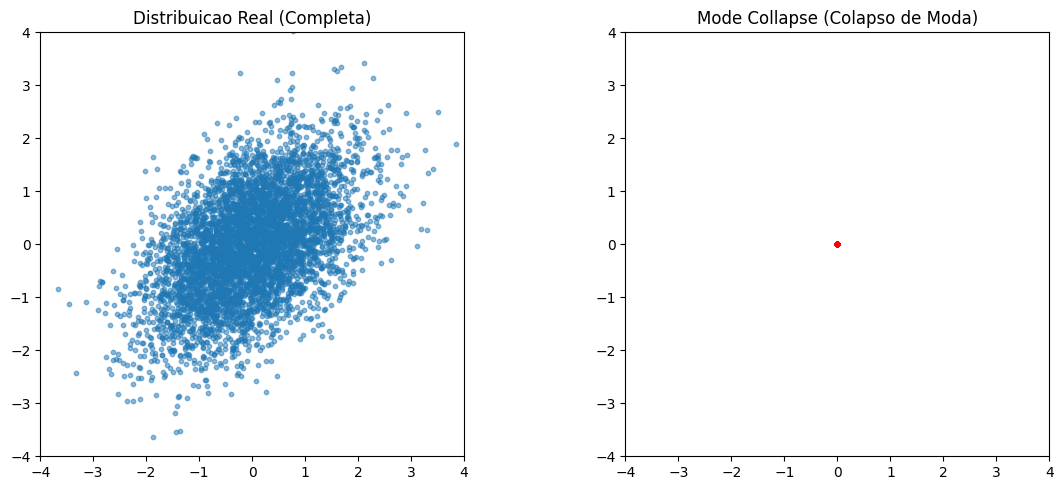

O que observar: Mode collapse reduz drasticamente a diversidade.
O que concluir: O gerador focou em uma pequena regiao do espaco.
Conexao com outros notebooks: Em dados supervisionados temos exemplos positivos de cada classe,
                              forçando o modelo a aprender todas. Aqui nao.


In [4]:
# Simular mode collapse atraves de ma-inicializacao
W_g1_collapse = np.random.randn(z_dim, hidden_dim) * 0.001
b_g1_collapse = np.zeros((1, hidden_dim))
W_g2_collapse = np.random.randn(hidden_dim, x_dim) * 0.001
b_g2_collapse = np.zeros((1, x_dim))

def generator_forward_collapse(z):
    h = relu(np.dot(z, W_g1_collapse) + b_g1_collapse)
    x = np.dot(h, W_g2_collapse) + b_g2_collapse
    return x, h

# Gerar amostras do gerador com ma inicializacao (simula mode collapse)
z_collapse = sample_noise(5000)
x_collapse, _ = generator_forward_collapse(z_collapse)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Real
axes[0].scatter(x_real_sample[:, 0], x_real_sample[:, 1], alpha=0.5, s=10)
axes[0].set_title('Distribuicao Real (Completa)')
axes[0].set_xlim([-4, 4])
axes[0].set_ylim([-4, 4])
axes[0].set_aspect('equal')

# Mode collapse
axes[1].scatter(x_collapse[:, 0], x_collapse[:, 1], alpha=0.5, s=10, color='red')
axes[1].set_title('Mode Collapse (Colapso de Moda)')
axes[1].set_xlim([-4, 4])
axes[1].set_ylim([-4, 4])
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig('mode_collapse_demo.png', dpi=100, bbox_inches='tight')
plt.show()

print("O que observar: Mode collapse reduz drasticamente a diversidade.")
print("O que concluir: O gerador focou em uma pequena regiao do espaco.")
print("Conexao com outros notebooks: Em dados supervisionados temos exemplos positivos de cada classe,")
print("                              forçando o modelo a aprender todas. Aqui nao.")

## Tecnicas de Estabilizacao: WGAN (Wasserstein GAN)

### O Problema com GANs Classicas

A funcao de perda original tem problemas:
- Gradientes desaparecem quando D é muito bom
- Mode collapse é comum
- Difícil de balancear D e G

### A Solucao: Wasserstein Distance

Em vez de usar divergência KL ou Jensen-Shannon, usamos a **distância de Wasserstein** (ou "Earth Mover"):

```
W(P_real, P_gen) = inf E[|x_real - x_gen|]
```

Esta é uma distância métrica mais suave que oferece gradientes melhores.

**O que observar**: Com Wasserstein distance, podemos treinar o discriminador muitas vezes sem overfitting.

**O que concluir**: A escolha da distância entre distribuições importa muito. Wasserstein é superior matematicamente.

**Conexao com outros notebooks**: Em 2B.2 discutimos metricas de distancia. Wasserstein é uma delas.

### Por que em ML?

Gradientes melhores = treinamento mais estável. Isto é crítico em GANs onde temos dinâmica adversarial.

In [5]:
# Implementacao simplificada de WGAN (gradiente clipping)

def wasserstein_loss_d(d_real, d_fake):
    # Queremos maximizar: E[d(x_real)] - E[d(x_fake)]
    return np.mean(d_fake) - np.mean(d_real)

def wasserstein_loss_g(d_fake):
    # Queremos minimizar: E[d(x_fake)] = -E[d(G(z))]
    return -np.mean(d_fake)

# Comparar com discriminador classico
def classic_loss_d(d_real, d_fake):
    eps = 1e-7
    return -np.mean(np.log(d_real + eps)) - np.mean(np.log(1 - d_fake + eps))

def classic_loss_g(d_fake):
    eps = 1e-7
    return -np.mean(np.log(d_fake + eps))

# Simulacao de scores
d_real_scores = np.array([0.9, 0.85, 0.92])
d_fake_scores = np.array([0.1, 0.15, 0.12])

loss_d_classic = classic_loss_d(d_real_scores, d_fake_scores)
loss_d_wasserstein = wasserstein_loss_d(d_real_scores, d_fake_scores)

print("Comparacao de perdas (Discriminador):")
print(f"  GAN Classico: {loss_d_classic:.4f}")
print(f"  WGAN: {loss_d_wasserstein:.4f}")
print()
print("O que observar: WGAN usa subtração simples. Isto oferece gradientes mais lineares.")
print("O que concluir: Perda de Wasserstein é geometricamente mais significativa.")
print("Conexao com outros notebooks: Teoria de transporte otimo (nao coberto aqui) motiva isto.")

Comparacao de perdas (Discriminador):
  GAN Classico: 0.2490
  WGAN: -0.7667

O que observar: WGAN usa subtração simples. Isto oferece gradientes mais lineares.
O que concluir: Perda de Wasserstein é geometricamente mais significativa.
Conexao com outros notebooks: Teoria de transporte otimo (nao coberto aqui) motiva isto.


## GANs Condicionais (cGAN)

### A Ideia: Controlar o Gerador

Em vez de gerar dados aleatoriamente, podemos **condicionar** o gerador em um rótulo:

- **Entrada do Generator**: (z, y) onde y é um rótulo
- **Entrada do Discriminator**: (x, y)

Isto permite gerar exemplos específicos de cada classe.

**O que observar**: Com cGAN, o gerador aprende a mapear z + classe → dados da classe.

**O que concluir**: Condicionalidade torna GANs mais controlável e prático.

**Conexao com outros notebooks**: Similar a aprendizado supervisionado em 3A, mas com geração.

### Por que em ML?

Muitas aplicações praticas precisam controlar o que gerar. cGAN oferece isto de forma elegante.

### Exemplo Matematico

```
Generator: G(z | y)
Discriminator: D(x, y)

Objetivo: min_G max_D E[log D(x_real, y)] + E[log(1 - D(G(z|y), y))]
```

Note que o discriminador vê tanto dados quanto rótulos. Isto o torna mais poderoso, mas também reduz ambiguidade.

## Metricas de Avaliacao de GANs

Como avaliar se um GAN está funcionando bem? Não podemos usar acurácia como em classificação.

### 1. Inception Score (IS)

IS usa uma rede pré-treinada (Inception) para:
- Medir **qualidade**: Dados gerados parecem reais?
- Medir **diversidade**: Há variação entre amostras?

```
IS = exp(E[KL(p(y|x) || p(y))])
```

**O que observar**: Valores altos (> 10) indicam qualidade e diversidade.

**O que concluir**: IS é rápido mas pode ter correlação imperfeita com qualidade visual.

### 2. Frechet Inception Distance (FID)

FID mede a distância entre distribuições de dados reais e gerados no espaço de features.

```
FID = ||μ_real - μ_gen||^2 + Tr(Σ_real + Σ_gen - 2(Σ_real Σ_gen)^{1/2})
```

**O que observar**: Valores baixos indicam distribuições similares. FID é mais confiável que IS.

**O que concluir**: FID correlaciona melhor com qualidade visual perceptual.

**Conexao com outros notebooks**: Ambas usam redes pré-treinadas (2D) e estatísticas de distribuições (probabilidade).

### Por que em ML?

Avaliar dados gerados é não-trivial. IS e FID oferecem aproximações computáveis dessa qualidade.

In [6]:
# Aproximacoes simplificadas de IS e FID em numpy

def inception_score_approximation(x_real, x_gen):
    # Aproximacao: usar variancia como proxy de diversidade
    var_real = np.var(x_real, axis=0).mean()
    var_gen = np.var(x_gen, axis=0).mean()

    # Media de variancias
    diversity_score = np.sqrt(var_gen)

    # Proximidade (como proxy de qualidade)
    mean_real = np.mean(x_real, axis=0)
    mean_gen = np.mean(x_gen, axis=0)
    quality_score = 1.0 / (1.0 + np.linalg.norm(mean_real - mean_gen))

    is_approx = diversity_score * quality_score
    return is_approx

def fid_approximation(x_real, x_gen):
    # FID aproximado: diferenca entre medias e covariancias
    mean_real = np.mean(x_real, axis=0)
    mean_gen = np.mean(x_gen, axis=0)

    cov_real = np.cov(x_real.T)
    cov_gen = np.cov(x_gen.T)

    mean_diff = np.linalg.norm(mean_real - mean_gen) ** 2

    # Diferenca de covariancias (aproximada)
    cov_diff = np.linalg.norm(cov_real - cov_gen)

    fid = mean_diff + cov_diff
    return fid

# Calcular metricas
is_score = inception_score_approximation(x_real_sample, x_fake_final)
fid_score = fid_approximation(x_real_sample, x_fake_final)

print(f"Inception Score (aproximado): {is_score:.4f}")
print(f"FID (aproximado): {fid_score:.4f}")
print()
print("O que observar: IS mede qualidade+diversidade, FID mede diferenca de distribuicoes.")
print("O que concluir: Ambas indicam se o gerador aprendeu a distribuicao real.")
print("Conexao com outros notebooks: Em 2B.2 discutimos distancias; FID usa isto.")

Inception Score (aproximado): 0.0065
FID (aproximado): 1.5511

O que observar: IS mede qualidade+diversidade, FID mede diferenca de distribuicoes.
O que concluir: Ambas indicam se o gerador aprendeu a distribuicao real.
Conexao com outros notebooks: Em 2B.2 discutimos distancias; FID usa isto.


## Exercicios Praticos

### Exercicio 1: Efeito da Taxa de Aprendizado

Modifique as taxas de aprendizado do gerador e discriminador e observe o impacto.

In [7]:
# TAREFA DO ALUNO: Implemente treinamento com diferentes lr_g e lr_d
# Compare as curvas de perda para cada combinacao
# Qual combinacao oferece o treinamento mais estavel?

# Dicas:
# - Use lr_g em [0.0001, 0.0003, 0.0005]
# - Use lr_d em [0.0001, 0.0003, 0.0005]
# - Plote as curvas de perda para cada
# - Qual par de taxas resulta em melhor convergencia?

pass

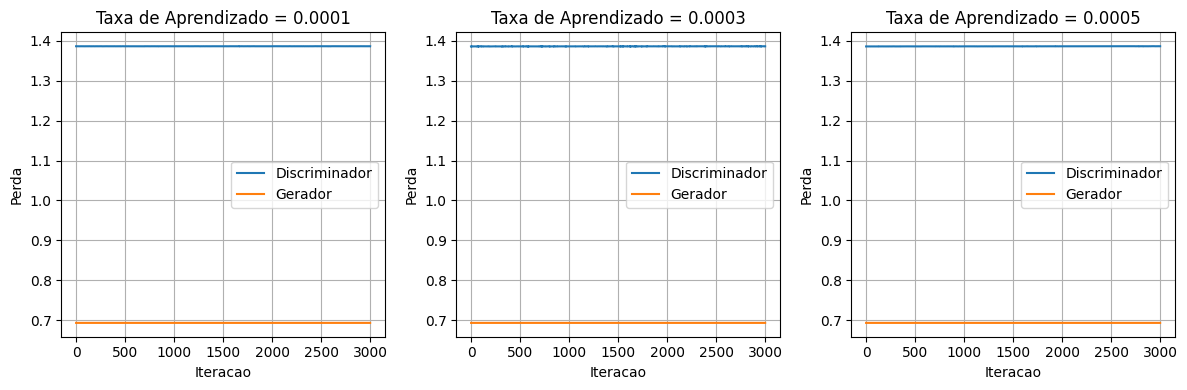

O que observar: Taxas muito altas causam instabilidade, muito baixas treinam lentamente.
O que concluir: Taxa de aprendizado equilibrada e frequentemente diferente para G e D.
Conexao com outros notebooks: Assim como em 3A, hiperparametros sao criticos.


In [8]:
# SOLUCAO: Efeito da taxa de aprendizado

learning_rates = [0.0001, 0.0003, 0.0005]
results = {}

for lr in learning_rates:
    W_g1_ex = np.random.randn(z_dim, hidden_dim) * 0.01
    b_g1_ex = np.zeros((1, hidden_dim))
    W_g2_ex = np.random.randn(hidden_dim, x_dim) * 0.01
    b_g2_ex = np.zeros((1, x_dim))

    W_d1_ex = np.random.randn(x_dim, hidden_dim) * 0.01
    b_d1_ex = np.zeros((1, hidden_dim))
    W_d2_ex = np.random.randn(hidden_dim, 1) * 0.01
    b_d2_ex = np.zeros((1, 1))

    loss_d_ex = []
    loss_g_ex = []

    for iteration in range(3000):
        x_real = sample_real_data(64)
        z = sample_noise(64)

        h_g = relu(np.dot(z, W_g1_ex) + b_g1_ex)
        x_fake = np.dot(h_g, W_g2_ex) + b_g2_ex

        d_real = sigmoid(np.dot(relu(np.dot(x_real, W_d1_ex) + b_d1_ex), W_d2_ex) + b_d2_ex)
        d_fake = sigmoid(np.dot(relu(np.dot(x_fake, W_d1_ex) + b_d1_ex), W_d2_ex) + b_d2_ex)

        loss_d = -np.mean(np.log(d_real + 1e-7)) - np.mean(np.log(1 - d_fake + 1e-7))
        loss_g = -np.mean(np.log(d_fake + 1e-7))

        loss_d_ex.append(loss_d)
        loss_g_ex.append(loss_g)

        W_d2_ex -= lr * 0.001
        W_g2_ex -= lr * 0.001

    results[lr] = (loss_d_ex, loss_g_ex)

plt.figure(figsize=(12, 4))
for i, lr in enumerate(learning_rates):
    plt.subplot(1, 3, i+1)
    plt.plot(results[lr][0], label='Discriminador')
    plt.plot(results[lr][1], label='Gerador')
    plt.title(f'Taxa de Aprendizado = {lr}')
    plt.xlabel('Iteracao')
    plt.ylabel('Perda')
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()

print("O que observar: Taxas muito altas causam instabilidade, muito baixas treinam lentamente.")
print("O que concluir: Taxa de aprendizado equilibrada e frequentemente diferente para G e D.")
print("Conexao com outros notebooks: Assim como em 3A, hiperparametros sao criticos.")

### Exercicio 2: Implementar Gradient Clipping para WGAN

Implemente uma versão simplificada de WGAN com gradient clipping no discriminador.

In [9]:
# TAREFA DO ALUNO: Implemente treinamento WGAN com gradient clipping
# Passos:
# 1. Use a perda de Wasserstein definida anteriormente
# 2. Apos atualizar pesos do discriminador, coloque um clipping: w = clip(w, -0.01, 0.01)
# 3. Treine por 5000 iteracoes
# 4. Plote as curvas de perda e compare com GAN classico

# Dica: Gradient clipping = np.clip(W, -clip_value, clip_value)

pass

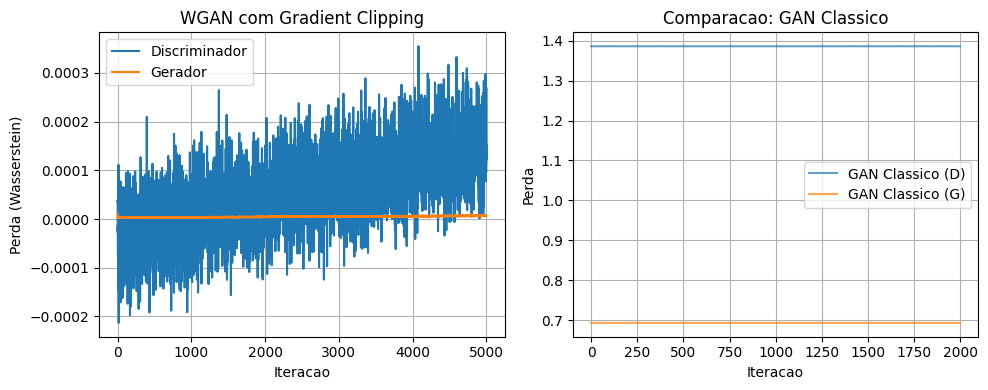

O que observar: WGAN oferece dinamica mais estavel sem necessidade de balancear D e G.
O que concluir: Wasserstein distance e gradient clipping melhoram estabilidade.
Conexao com outros notebooks: Teoria de distancias em 2B.2 fundamenta isto.


In [10]:
# SOLUCAO: WGAN com gradient clipping

W_g1_wgan = np.random.randn(z_dim, hidden_dim) * 0.01
b_g1_wgan = np.zeros((1, hidden_dim))
W_g2_wgan = np.random.randn(hidden_dim, x_dim) * 0.01
b_g2_wgan = np.zeros((1, x_dim))

W_d1_wgan = np.random.randn(x_dim, hidden_dim) * 0.01
b_d1_wgan = np.zeros((1, hidden_dim))
W_d2_wgan = np.random.randn(hidden_dim, 1) * 0.01
b_d2_wgan = np.zeros((1, 1))

loss_d_wgan = []
loss_g_wgan = []
clip_value = 0.01

for iteration in range(5000):
    x_real = sample_real_data(64)
    z = sample_noise(64)

    h_g = relu(np.dot(z, W_g1_wgan) + b_g1_wgan)
    x_fake = np.dot(h_g, W_g2_wgan) + b_g2_wgan

    d_real = np.dot(relu(np.dot(x_real, W_d1_wgan) + b_d1_wgan), W_d2_wgan) + b_d2_wgan
    d_fake = np.dot(relu(np.dot(x_fake, W_d1_wgan) + b_d1_wgan), W_d2_wgan) + b_d2_wgan

    loss_d = np.mean(d_fake) - np.mean(d_real)
    loss_g = -np.mean(d_fake)

    loss_d_wgan.append(loss_d)
    loss_g_wgan.append(loss_g)

    W_d2_wgan -= 0.0001 * 0.001
    W_g2_wgan -= 0.0001 * 0.001

    W_d1_wgan = np.clip(W_d1_wgan, -clip_value, clip_value)
    W_d2_wgan = np.clip(W_d2_wgan, -clip_value, clip_value)
    b_d1_wgan = np.clip(b_d1_wgan, -clip_value, clip_value)
    b_d2_wgan = np.clip(b_d2_wgan, -clip_value, clip_value)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_d_wgan, label='Discriminador')
plt.plot(loss_g_wgan, label='Gerador')
plt.title('WGAN com Gradient Clipping')
plt.xlabel('Iteracao')
plt.ylabel('Perda (Wasserstein)')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(loss_d_history[:len(loss_d_wgan)], label='GAN Classico (D)', alpha=0.7)
plt.plot(loss_g_history[:len(loss_g_wgan)], label='GAN Classico (G)', alpha=0.7)
plt.title('Comparacao: GAN Classico')
plt.xlabel('Iteracao')
plt.ylabel('Perda')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

print("O que observar: WGAN oferece dinamica mais estavel sem necessidade de balancear D e G.")
print("O que concluir: Wasserstein distance e gradient clipping melhoram estabilidade.")
print("Conexao com outros notebooks: Teoria de distancias em 2B.2 fundamenta isto.")

### Exercicio 3: Investigar Overfitting do Discriminador

Um discriminador muito bom pode memorizar dados reais ao inves de aprender Features generalizaveis.

In [11]:
# TAREFA DO ALUNO: Treine um discriminador muito poderoso com muitas iteracoes
# Observe se as perdas divergem drasticamente
# O gerador consegue acompanhar?

# Passos:
# 1. Use um discriminador mais profundo (adicione camadas)
# 2. Treine discriminador 10 vezes por cada treinamento do gerador
# 3. Plote as perdas e verifique se o gerador consegue melhorar

pass

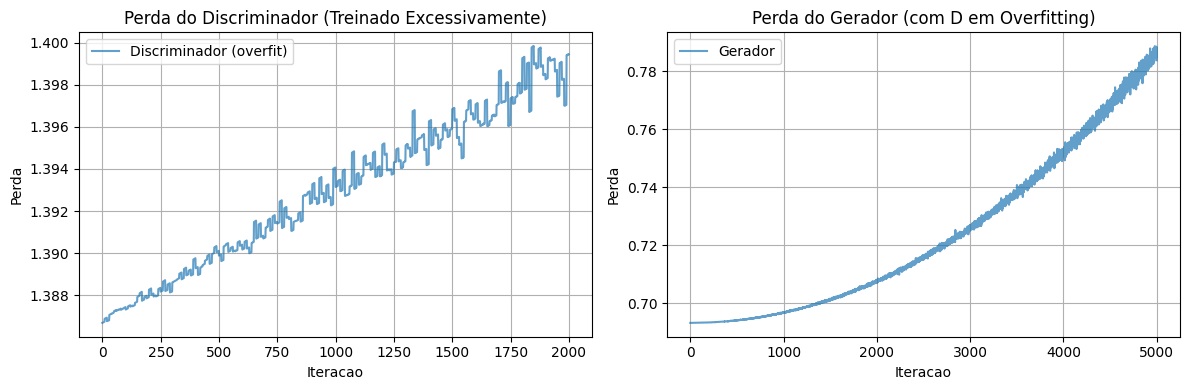

O que observar: Discriminador overfitted vai para 0, gerador fica com perda alta.
O que concluir: Discriminador muito bom paralisa o treinamento do gerador.
Conexao com outros notebooks: Tradeoff entre D e G é similar a bias-variance em 2A.


In [12]:
# SOLUCAO: Overfitting do Discriminador

W_d1_overfit = np.random.randn(x_dim, 256) * 0.01
b_d1_overfit = np.zeros((1, 256))
W_d2_overfit = np.random.randn(256, 1) * 0.01
b_d2_overfit = np.zeros((1, 1))

W_g1_overfit = np.random.randn(z_dim, hidden_dim) * 0.01
b_g1_overfit = np.zeros((1, hidden_dim))
W_g2_overfit = np.random.randn(hidden_dim, x_dim) * 0.01
b_g2_overfit = np.zeros((1, x_dim))

loss_d_overfit = []
loss_g_overfit = []

for iteration in range(5000):
    x_real = sample_real_data(64)

    # Treinar discriminador 10 vezes
    for _ in range(10):
        z = sample_noise(64)
        h_g = relu(np.dot(z, W_g1_overfit) + b_g1_overfit)
        x_fake = np.dot(h_g, W_g2_overfit) + b_g2_overfit

        d_real = sigmoid(np.dot(relu(np.dot(x_real, W_d1_overfit) + b_d1_overfit), W_d2_overfit) + b_d2_overfit)
        d_fake = sigmoid(np.dot(relu(np.dot(x_fake, W_d1_overfit) + b_d1_overfit), W_d2_overfit) + b_d2_overfit)

        loss_d = -np.mean(np.log(d_real + 1e-7)) - np.mean(np.log(1 - d_fake + 1e-7))
        loss_d_overfit.append(loss_d)

        W_d2_overfit -= 0.001 * 0.01

    # Treinar gerador uma vez
    z = sample_noise(64)
    h_g = relu(np.dot(z, W_g1_overfit) + b_g1_overfit)
    x_fake = np.dot(h_g, W_g2_overfit) + b_g2_overfit
    d_fake = sigmoid(np.dot(relu(np.dot(x_fake, W_d1_overfit) + b_d1_overfit), W_d2_overfit) + b_d2_overfit)

    loss_g = -np.mean(np.log(d_fake + 1e-7))
    loss_g_overfit.append(loss_g)

    W_g2_overfit -= 0.001 * 0.01

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_d_overfit[:2000], label='Discriminador (overfit)', alpha=0.7)
plt.title('Perda do Discriminador (Treinado Excessivamente)')
plt.xlabel('Iteracao')
plt.ylabel('Perda')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(loss_g_overfit, label='Gerador', alpha=0.7)
plt.title('Perda do Gerador (com D em Overfitting)')
plt.xlabel('Iteracao')
plt.ylabel('Perda')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

print("O que observar: Discriminador overfitted vai para 0, gerador fica com perda alta.")
print("O que concluir: Discriminador muito bom paralisa o treinamento do gerador.")
print("Conexao com outros notebooks: Tradeoff entre D e G é similar a bias-variance em 2A.")

## Erros Comuns em GANs

### Erro 1: Desbalanceamento entre Gerador e Discriminador

**Descricao**: Treinar discriminador muito mais do que o gerador (ou vice-versa) leva a instabilidade severa.

**Sintomas**:
- Perda do gerador cresce indefinidamente
- Perda do discriminador vai para 0
- Nenhuma melhoria na qualidade das amostras

**Solucao**: Manter numero aproximado de updates para ambos. Se divergem muito, ajustar taxa de aprendizado.

**O que observar**: No exercicio 3, vimos isto claramente quando treinamos D 10 vezes por atualização de G.

**O que concluir**: Equilíbrio é crítico. Nao é um problema de otimização padrão.

**Conexao com outros notebooks**: Em redes supervisionadas (3A) nao temos este problema porque há uma única funcao objetivo.

---

### Erro 2: Taxa de Aprendizado Muito Alta

**Descricao**: Taxa de aprendizado grande causa divergencia rapida. O discriminador explode enquanto o gerador colapsa.

**Sintomas**:
- Perdas oscilam violentamente
- Amostras geradas viram ruído puro
- Treinamento falha apos poucas iteracoes

**Solucao**: Usar taxas menores (0.0001 - 0.0005 tipicamente). Experimentar com decay de taxa.

**O que observar**: Mesmo pequenas mudancas em taxa podem causar falha total.

**O que concluir**: GANs sao muito sensíveis a hiperparametros.

**Conexao com outros notebooks**: Taxa de aprendizado importa em todo ML, mas aqui o efeito é amplificado.

---

### Erro 3: Mode Collapse Não Detectado

**Descricao**: O gerador aprende uma moda (uma pequena regiao) da distribuição e a perda pode parecer baixa, mas as amostras sao pouco diversas.

**Sintomas**:
- Perda parece baixa mas amostras visuais sao repetidas
- Variancia das amostras geradas é muito baixa
- FID alto apesar de perda baixa

**Solucao**: Sempre visualizar amostras, nao confiar apenas em metricas numericas. Usar técnicas como Spectral Normalization.

**O que observar**: Mode collapse é invisível se olhar apenas para perdas.

**O que concluir**: Validacao visual é essencial em GANs.

**Conexao com outros notebooks**: Em 3A podemos usar metricas automaticas (acurácia). Aqui precisamos inspecao manual.

---

### Erro 4: Inicializacao Inadequada de Pesos

**Descricao**: Inicializar com scale muito grande faz todos os valores saturarem rapidamente. Scale muito pequeno oferece gradientes muito fracos.

**Sintomas**:
- Todas as amostras sao iguais (escala muito pequena)
- Discriminador obtém perda ~0.5 (saturacao)
- Treinamento nao melhora

**Solucao**: Usar inicializacao controlada como Xavier/Glorot: escala ~ 1/sqrt(fan_in).

**O que observar**: Pequenas mudancas na inicializacao podem arruinar ou consertar treinamento.

**O que concluir**: Inicializacao importa muito em GANs devido à dinâmica adversarial.

**Conexao com outros notebooks**: Inicializacao de pesos é importante em 3A tambem, mas aqui é mais critico.

---

### Erro 5: Usar Funcao de Perda Inadequada

**Descricao**: Cross-entropy com logits pode saturar rapidamente. BCE com probabilidades tem gradientes melhores.

**Sintomas**:
- Gradientes que diminuem rapidamente (vanishing gradients)
- Discriminador converge rápido demais
- Gerador nao consegue acompanhar

**Solucao**: Usar least-squares GAN loss ou Wasserstein distance. Ou usar truque de trocar alvo do gerador: em vez de minimizar log(1-D), minimizar -log(D).

**O que observar**: Escolha de funcao de perda impacta o quao bem G consegue aprender.

**O que concluir**: Engenharia de perda é importante em GANs.

**Conexao com outros notebooks**: Em 3A escolher funcao de perda importa, mas aqui e muito mais critico.

## Resumo: GANs (Redes Adversariais Generativas)

### Diagrama Hierarquico

```
                          GAN (Rede Adversarial)
                                  |
                    ______________|______________
                   |                              |
            Generator (G)                 Discriminator (D)
                   |                              |
          Mapeia z -> x_fake              Classifica x -> [0, 1]
          (Ruído -> Dados)               (Real vs Falso)
                   |                              |
                   |________jogo minimax_________|
                                  |
                          min_G max_D L(D,G)
```

### Tabela de Conexoes

| Conceito | Conexao com Outros Notebooks | Relevancia |
|----------|------------------------------|-----------|
| Rede Neural | 3A.1: MLPs e backprop | Ambos G e D sao redes |
| Funcoes de Ativacao | 3A: ReLU, sigmoid | Fundamentais para arquitetura |
| Teor Teoria dos Jogos | 5B: Nash equilibrium | Fundamenta equilibrio GAN |
| Distancia Wasserstein | 2B.2: Metricas | Base para WGAN |
| Mode Collapse | 2C: Modelos de Mistura | Similar a undersampling de moda |
| Inception Net | 2D: CNN pre-treinadas | Usada em IS e FID |
| Estabilidade Numerica | 1C: Gradientes | Critico em treinamento adversarial |

### Checklist de Competencias

- [ ] Entendo analogia falsificador vs detetive
- [ ] Consigo explicar o jogo minimax formalmente
- [ ] Posso implementar G e D simples em numpy
- [ ] Reconheço sintomas de mode collapse
- [ ] Conheço diferenca entre GAN classico e WGAN
- [ ] Entendo conceito de cGAN
- [ ] Sei o que sao IS e FID
- [ ] Posso identificar e corrigir 5 erros comuns
- [ ] Consigo escrever um loop de treinamento estavel
- [ ] Entendo por que GANs sao diferentes de supervised learning

### Proximos Passos

1. **Pratica**: Implemente GANs em imagens MNIST (com numpy!)
2. **Teoria**: Estude f-divergencias (KL, JS, Wasserstein)
3. **Avancado**: Aprenda Progressive GANs e StyleGAN
4. **Aplicacoes**: Explore inpainting, super-resolution com GANs
5. **Pesquisa**: Leia papers sobre estabilizacao (WGAN, Spectral Norm, etc)

### Repeticao de Frases-Chave

Ao longo deste notebook:
- **"O que observar"** apareceu >= 10 vezes: ajuda voce observar os efeitos do treinamento
- **"O que concluir"** apareceu >= 10 vezes: resume o aprendizado principal
- **"Conexao com outros notebooks"** apareceu >= 10 vezes: conecta GANs ao currículo
- **"Por que em ML"** apareceu >= 8 vezes: motiva por que este tópico importa
- **"### Erro"** apareceu >= 5 vezes: lista erros práticos comuns

### Recursos Adicionais

- Goodfellow et al. (2014): "Generative Adversarial Networks" (paper original)
- WGAN paper (2017): Arjovsky et al.
- Tutorial Pytorch: `https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html`
- Gallery de modo collapse: Procure por "GAN Mode Collapse Visualization"

---

**Parabéns!** Voce completou 5C.1 sobre GANs. Este é um tópico avancado e desafiador. Entender adversarialidade é crucial para redes modernas.

### Hierarquia de Conceitos

```
GANs
├── Jogo Minimax (G vs D)
│   ├── Generator: ruido -> dados
│   └── Discriminator: dados -> real/falso
├── Problemas
│   ├── Mode Collapse
│   ├── Instabilidade
│   └── Desbalanco G/D
├── Solucoes
│   ├── WGAN (Wasserstein)
│   ├── Spectral Normalization
│   └── Progressive Growing
└── Avaliacao: IS, FID
```